# Phase 1: Problem Framing, Data Understanding & EDA
### IT24103052 — Sukirthan.C

## 1.1 Business Problem Statement
**Formal problem statement:** A Portuguese bank wants to predict whether a customer will subscribe to a term deposit (y) based on demographic, financial, and campaign features. This is a binary classification task.

**Primary lens:** Campaign Response Prediction.
**Secondary lens:** Marketing Profile Analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('data/bank-full.csv', sep=';')
print(f'Dataset Shape: {df.shape}')
display(df.head())

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 1.2 Data Dictionary

In [3]:
print('--- Dataset Info ---')
df.info()
print('\n--- Data Types ---')
print(df.dtypes)

data_dictionary = pd.DataFrame({
    'Feature': ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y'],
    'Type': ['numeric', 'categorical', 'categorical', 'categorical', 'categorical', 'numeric', 'categorical', 'categorical', 'categorical', 'numeric', 'categorical', 'numeric', 'numeric', 'numeric', 'numeric', 'categorical', 'categorical'],
    'Description': ['Age of the client', 'Type of job', 'Marital status', 'Education level', 'Has credit in default?', 'Average yearly balance, in euros', 'Has housing loan?', 'Has personal loan?', 'Contact communication type', 'Last contact day of the month', 'Last contact month of year', 'Last contact duration, in seconds (data leakage)', 'Number of contacts performed during this campaign', 'Number of days that passed by after the client was last contacted from a previous campaign', 'Number of contacts performed before this campaign', 'Outcome of the previous marketing campaign', 'Has the client subscribed a term deposit?'],
    'Role': ['Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Predictor/Leakage', 'Predictor', 'Predictor', 'Predictor', 'Predictor', 'Target']
})
display(data_dictionary)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB

--- Data Types ---
age          int64
job            str
marital        str
education      str
default        s

,Feature,Type,Description,Role
0,age,numeric,Age of the client,Predictor
1,job,categorical,Type of job,Predictor
2,marital,categorical,Marital status,Predictor
3,education,categorical,Education level,Predictor
4,default,categorical,Has credit in default?,Predictor
5,balance,numeric,"Average yearly balance, in euros",Predictor
6,housing,categorical,Has housing loan?,Predictor
7,loan,categorical,Has personal loan?,Predictor
8,contact,categorical,Contact communication type,Predictor
9,day,numeric,Last contact day of the month,Predictor


## 1.3 Target Variable Distribution

--- Target Variable Counts ---
y
no     39922
yes     5289
Name: count, dtype: int64

--- Target Variable Percentages (%) ---
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

Class Ratio (No:Yes) roughly 8:1


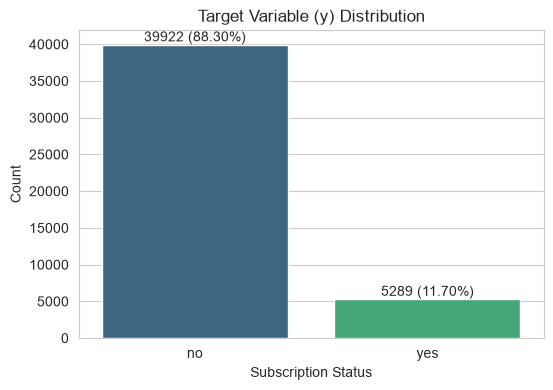


NOTE: Significant class imbalance detected (approx 88% No, 12% Yes).


In [4]:
target_counts = df['y'].value_counts()
target_percentages = df['y'].value_counts(normalize=True) * 100

print('--- Target Variable Counts ---')
print(target_counts)
print('\n--- Target Variable Percentages (%) ---')
print(target_percentages)
print(f'\nClass Ratio (No:Yes) roughly {round(target_counts["no"]/target_counts["yes"])}:1')

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Target Variable (y) Distribution')
plt.xlabel('Subscription Status')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.2f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points')
plt.show()
print('\nNOTE: Significant class imbalance detected (approx 88% No, 12% Yes).')

## 1.4 Duplicate Check

In [5]:
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')
print('Decision: No duplicates found. If any existed, we would remove them.')

Number of duplicate rows: 0
Decision: No duplicates found. If any existed, we would remove them.


## 1.5 Missing & Unknown Value Analysis

In [6]:
print('--- Missing Values (NaN) ---')
print(df.isnull().sum())

unknown_counts = []
for col in df.select_dtypes(include=['object']).columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        unknown_counts.append({'Feature': col, 'Unknown Count': count, 'Percentage (%)': round(count / len(df) * 100, 2)})

if unknown_counts:
    unknown_df = pd.DataFrame(unknown_counts)
    print('\n--- Unknown Values Analysis ---')
    display(unknown_df)
else:
    print('\nNo "unknown" values found.')

--- Missing Values (NaN) ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

--- Unknown Values Analysis ---


,Feature,Unknown Count,Percentage (%)
0,job,288,0.64
1,education,1857,4.11
2,contact,13020,28.80
3,poutcome,36959,81.75


## 1.6 Univariate Analysis — Numerical Features

--- Skewness of Numerical Features ---
age: 0.68
balance: 8.36
day: 0.09
duration: 3.14
campaign: 4.90
pdays: 2.62
previous: 41.85


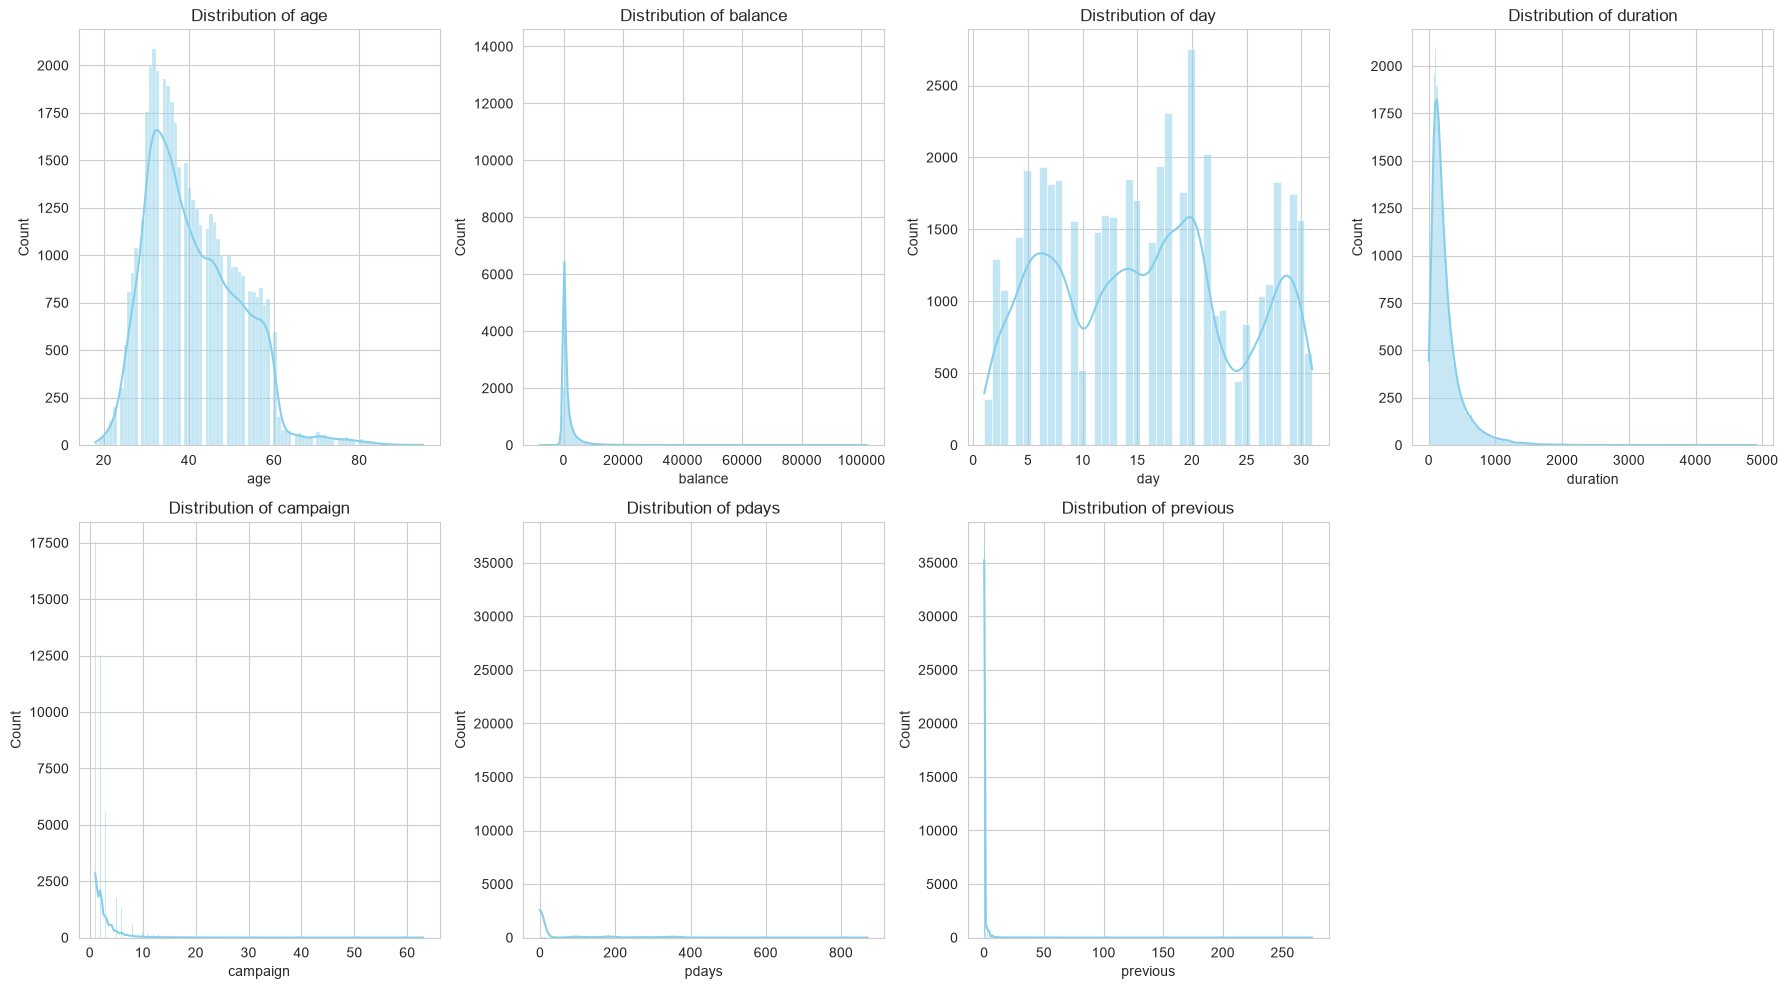

In [7]:
numeric_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

print('--- Skewness of Numerical Features ---')
for i, col in enumerate(numeric_features):
    print(f'{col}: {df[col].skew():.2f}')
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

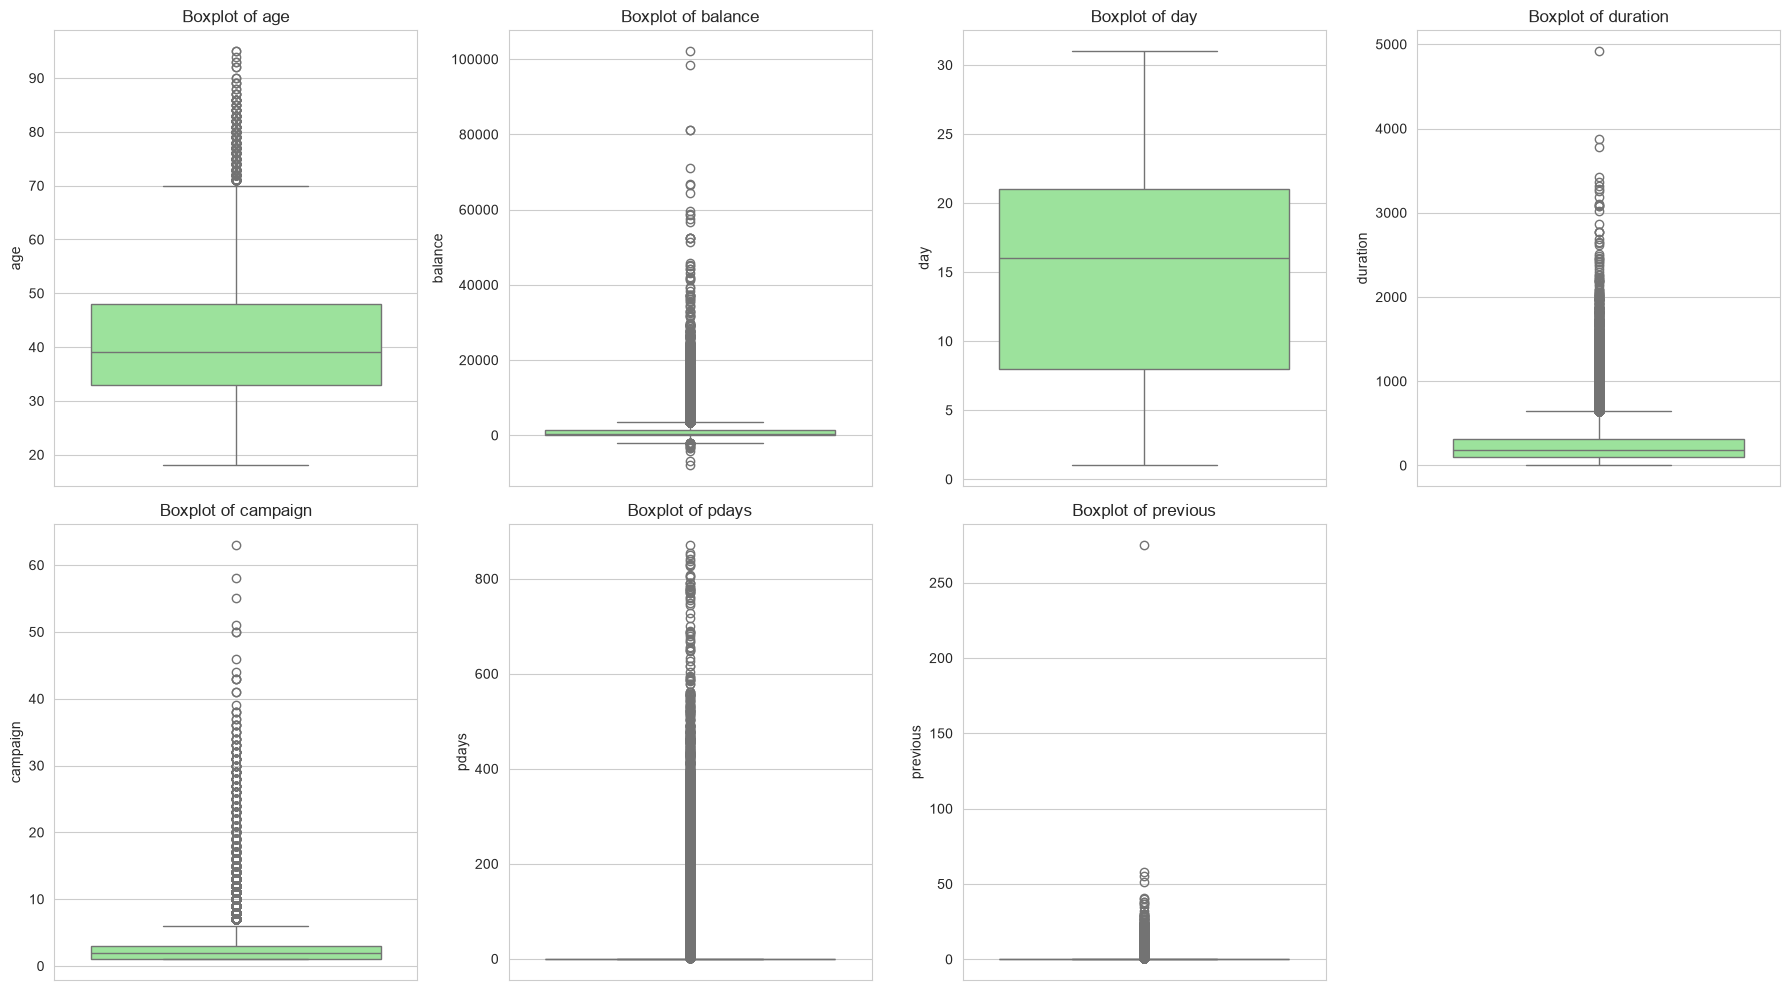

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 1.7 Univariate Analysis — Categorical Features

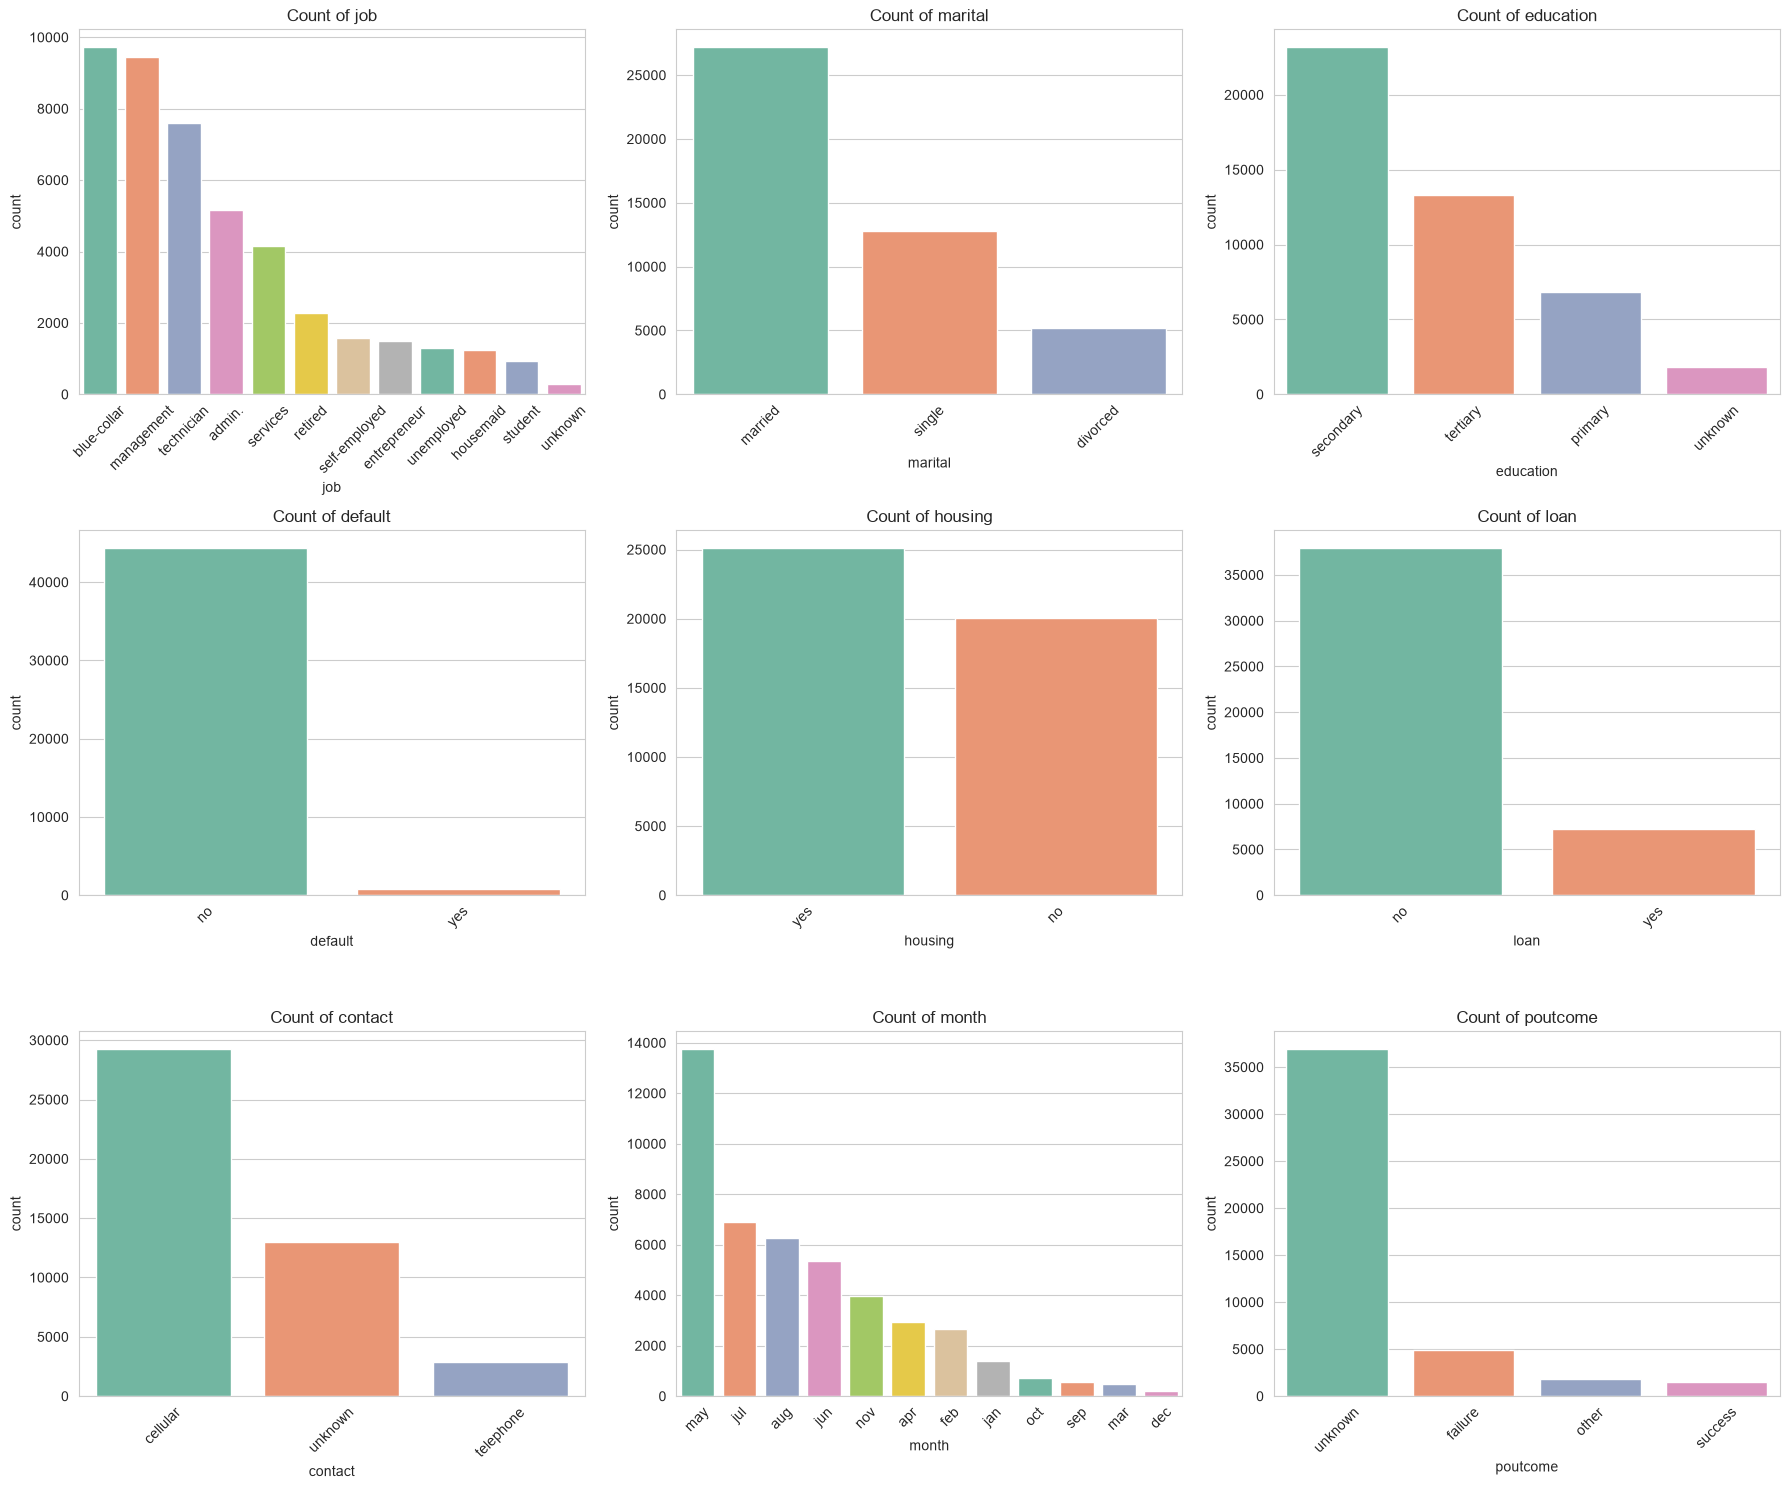

In [9]:
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=df, ax=axes[i], palette='Set2', order=df[col].value_counts().index)
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 1.8 Bivariate Analysis — Features vs Target

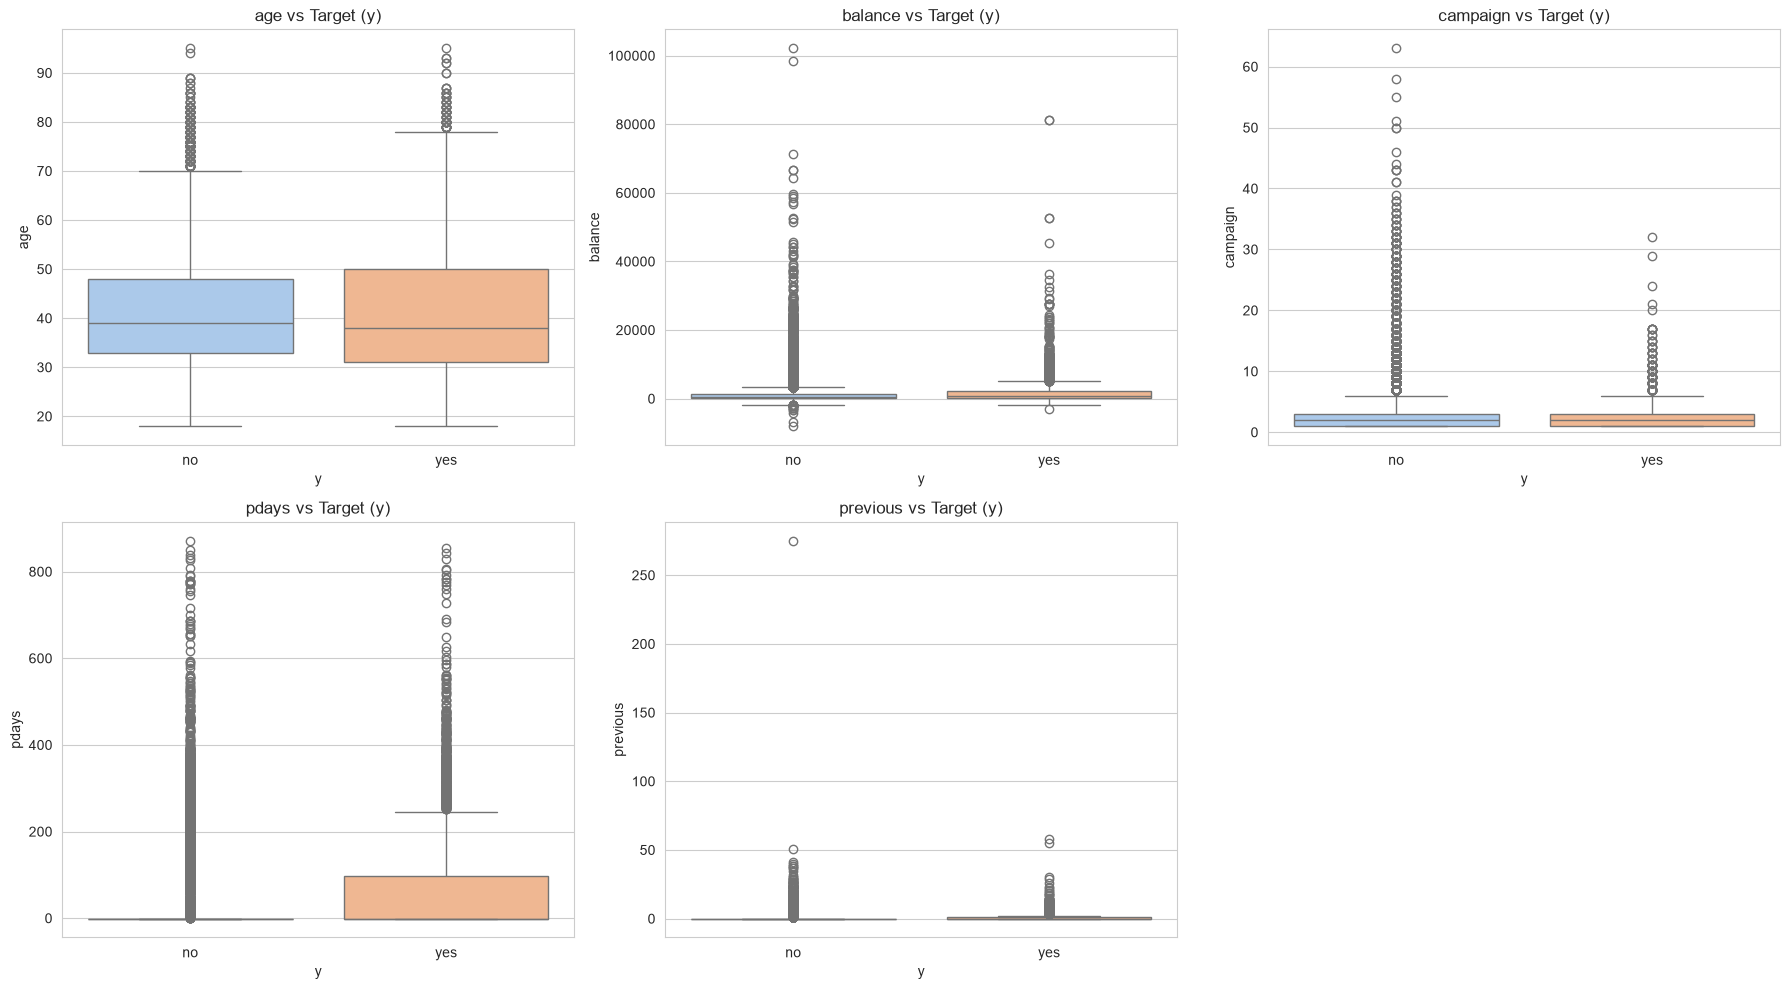

In [10]:
bivariate_numeric = ['age', 'balance', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(bivariate_numeric):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} vs Target (y)')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

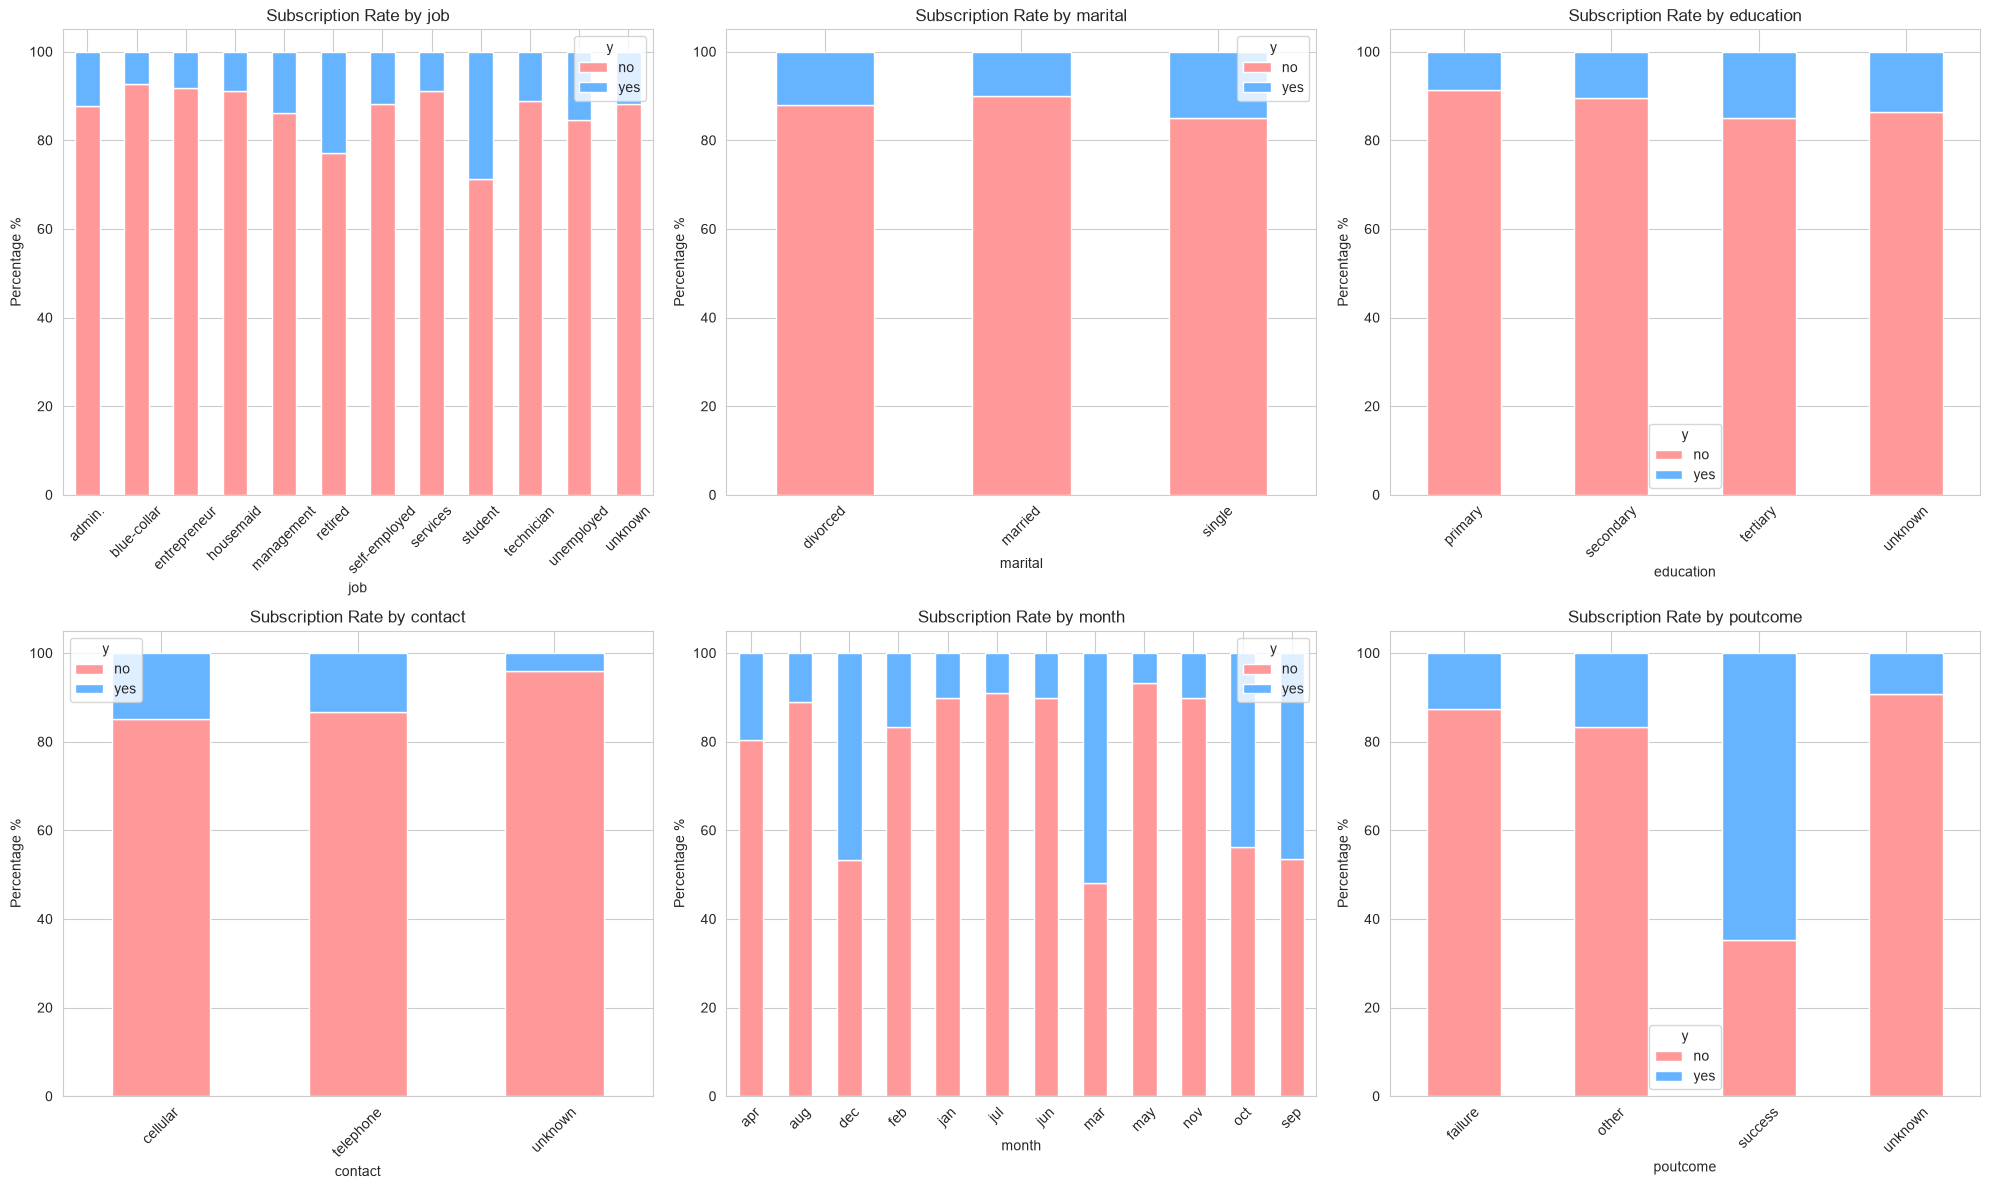

In [11]:
bivariate_categorical = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(bivariate_categorical):
    cross_tab = pd.crosstab(df[col], df['y'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#ff9999', '#66b3ff'])
    axes[i].set_title(f'Subscription Rate by {col}')
    axes[i].set_ylabel('Percentage %')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 1.9 Correlation Analysis

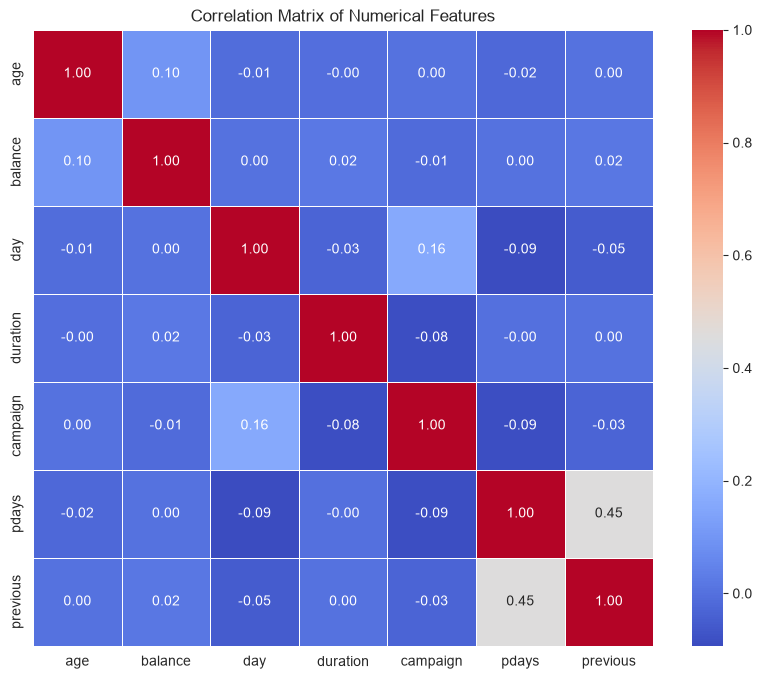


Comment on Multicollinearity:
- `pdays` and `previous` show a moderate positive correlation (0.45).
- Generally, multicollinearity among numerical features is low.


In [12]:
corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print('\nComment on Multicollinearity:')
print('- `pdays` and `previous` show a moderate positive correlation (0.45).')
print('- Generally, multicollinearity among numerical features is low.')

## 1.10 Data Leakage Warning — Duration

In [13]:
print('--- Data Leakage Demonstration: `duration` ---')
zero_duration = df[df['duration'] == 0]
print(f'Records with duration=0: {len(zero_duration)}')
print(f'Target distribution for duration=0: {zero_duration["y"].unique()}')

print('\nWARNING: `duration` highly affects the output target (e.g., if duration=0 then y="no").')
print('Yet, the duration is not known before a call is performed. Thus, it should be dropped for a realistic predictive model.')

df['y_numeric'] = df['y'].map({'no': 0, 'yes': 1})
corr_duration_y = df[['duration', 'y_numeric']].corr().iloc[0, 1]
print(f'\nCorrelation between `duration` and target `y`: {corr_duration_y:.2f}')

--- Data Leakage Demonstration: `duration` ---
Records with duration=0: 3
Target distribution for duration=0: <ArrowStringArray>
['no']
Length: 1, dtype: str

Yet, the duration is not known before a call is performed. Thus, it should be dropped for a realistic predictive model.

Correlation between `duration` and target `y`: 0.39


## 1.11 Subscriber Profile Summary
Insights about typical subscribers.

In [14]:
subscribers = df[df['y'] == 'yes']
print('--- Typical Subscriber Profile ---')
print(f"Mean Age: {subscribers['age'].mean():.1f} years")
print(f"Mean Balance: {subscribers['balance'].mean():.2f} euros")
print(f"Top Job: {subscribers['job'].mode()[0]}")
print(f"Top Education: {subscribers['education'].mode()[0]}")
print(f"Top Contact Method: {subscribers['contact'].mode()[0]}")
print(f"Top Previous Outcome (poutcome): {subscribers['poutcome'].mode()[0]}")

--- Typical Subscriber Profile ---
Mean Age: 41.7 years
Mean Balance: 1804.27 euros
Top Job: management
Top Education: secondary
Top Contact Method: cellular
Top Previous Outcome (poutcome): unknown


## 1.12 EDA Insight Log

1. **Class Imbalance:** Target variable `y` is highly imbalanced (88.3% 'no', 11.7% 'yes'). Resampling or weighted loss functions will be needed.
2. **Unknowns:** Categorical columns like `poutcome`, `contact`, `education`, and `job` contain 'unknown' strings instead of NaNs. `poutcome` has >80% unknowns.
3. **Skewness & Outliers:** Most numerical features (`balance`, `campaign`, `pdays`, `previous`) are highly right-skewed with significant outliers.
4. **Leakage:** The `duration` feature has a direct relationship with the target and represents data leakage. It must be dropped before training predictive models.
5. **Subscriber Characteristics:** Subscribers are typically in management, have tertiary education, are contacted via cellular, and tend to have higher call durations (though duration is leaky).